In [1]:
import copy
import cv2
import glob
import math
import matplotlib.pyplot as plt
from matplotlib import colors
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import numpy as np
import os
import pandas as pd
import seaborn as sns
from astropy.io import fits
import torch
from torch.utils.data import Dataset
from torchmetrics import Dice
from torchmetrics import Dice, JaccardIndex
import segmentation_models_pytorch as smp

/home2/dario/.local/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
hiperparametros = {'nombre_notebook': 'Evaluation_NISP_J_1000imgs_v13_log_no_aug_real_crops.ipynb',
                    'nombre_experimento' : 'Evaluation_NISP_J_1000imgs_v13_log_no_aug_pad_real_crops',
                    'nombre_mejor_modelo_entrenado' : '../NISP_J_1000imgs_v13_log_no_aug_pad',
                    'device' : torch.device("cuda:0" if torch.cuda.is_available() else "cpu"),
                    'ruta_galaxias' : 'real_tidal_tails_crops_without_pedestal/NISP_J/*.fits',
                    'ruta_mascaras' : '', #No masks
                    'ancho_imagen_original' : 200,
                    'alto_imagen_original' : 200,
                    'ancho_imagen_deseado' : 224,
                    'alto_imagen_deseado' : 224}

In [3]:
def pad_to_size(image, target_h, target_w, pad_value=0):
    """Hace padding para alcanzar el tamaño deseado sin deformar"""
    h, w = image.shape[:2]
    pad_h = target_h - h
    pad_w = target_w - w
    
    # Padding simétrico
    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left
    
    if len(image.shape) == 2:  # Para máscaras
        return np.pad(image, ((pad_top, pad_bottom), (pad_left, pad_right)), 
                     mode='constant', constant_values=pad_value)
    else:  # Para imágenes RGB
        return np.pad(image, ((pad_top, pad_bottom), (pad_left, pad_right), (0, 0)), 
                     mode='constant', constant_values=pad_value)


In [4]:
def normalize_01(inp: np.ndarray):
    """Squash image input to the value range [0, 1] (no clipping)"""
    inp_out = (inp - np.min(inp)) / np.ptp(inp)
    return inp_out

def imagen_logaritmica(img: np.ndarray)->np.ndarray:
    """
    Escalamos de forma logarítmica la imagen para aumentar el contraste
    """
    img_log = np.log(img, where=(img>0))
    valor_minimo = np.min(img_log)
    np.putmask(img_log, img!=0, img_log+abs(valor_minimo))
    return img_log

In [5]:
class MyDataset(Dataset):
    """
    Dataset básico sin ningún tipo de augmentation
    """
    def __init__(self, galaxias_con_colas_de_marea, transform=None):
        """
        Constructor del dataset
        @param galaxias_con_colas_de_marea: Lista de rutas a los ficheros que contienen los datos de las galaxias
        """
        self.galaxias_con_colas_de_marea = galaxias_con_colas_de_marea
        self.transform=transform

    def __getitem__(self, index):
        #Abrimos la imagen de la galaxia con cola de marea
        ruta = self.galaxias_con_colas_de_marea[index]
        
        galaxy_fits = fits.open(self.galaxias_con_colas_de_marea[index])
        x = galaxy_fits[0].data.astype(np.float32)
        #x = normalize_01(x)
        x_tensor_visualizar = copy.deepcopy(x)
        x = imagen_logaritmica(x)

        x = normalize_01(x)

        x = pad_to_size(x, hiperparametros['alto_imagen_deseado'], hiperparametros['ancho_imagen_deseado'])
        if(self.transform is not None):
            augmented = self.transform(image=x)
            x_tensor= augmented["image"]
        else:
            x_tensor = torch.from_numpy(x).float()
            x_tensor=torch.unsqueeze(x_tensor, dim=0)
        
        #Hacemos reshape de los tensores
        return x_tensor, None, ruta, None, x_tensor_visualizar, None, None
    
    def __len__(self):
        """
        Devuelve la longitud del dataset
        """
        return len(self.galaxias_con_colas_de_marea)

In [6]:
dice = Dice(num_classes=2, average='macro', ignore_index=0)
iou = JaccardIndex(task='multiclass', num_classes=2, average='none', ignore_index=0)
imagenes_test = glob.glob(hiperparametros['ruta_galaxias'])
imagenes_test.sort()
#Cargamos el dataset de test
test_dataset= MyDataset(imagenes_test)
print("Number of valid images: " + str(len(imagenes_test)))
device = hiperparametros['device']
#dice.to(device)

Number of valid images: 5


In [7]:
unet = smp.Unet(
    encoder_name="resnet18",        # choose encoder, e.g. mobilenet_v2 or efficientnet-b7
    encoder_weights="imagenet",     # use `imagenet` pre-trained weights for encoder initialization
    in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
    classes=2,                      # model output channels (number of classes in your dataset)
)

In [8]:
#Cargamos el modelo previamente entrenado
ruta_modelo = hiperparametros['nombre_mejor_modelo_entrenado']
mejor_modelo = unet
mejor_modelo.load_state_dict(torch.load(ruta_modelo))
mejor_modelo.to(device)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

min_sb: 18.896
max_sb: 19.888325
Path: real_tidal_tails_crops_without_pedestal/NISP_J/VIS_15180_35761_NISP_5060_11920.fits


/tmp/ipykernel_2784450/1858522200.py:37: RuntimeWarning: divide by zero encountered in log10
  sb_array = -2.5 * np.log10(x_tensor_visualizar) + zp + (5 * np.log10(pix_scale))


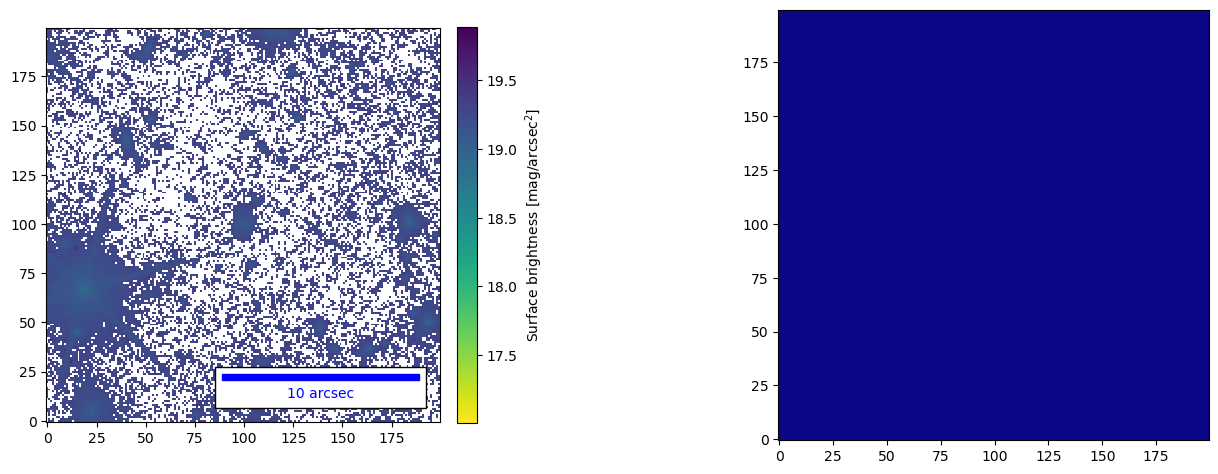

min_sb: 18.896
max_sb: 19.826664
Path: real_tidal_tails_crops_without_pedestal/NISP_J/VIS_23028_35285_NISP_7676_11761.fits


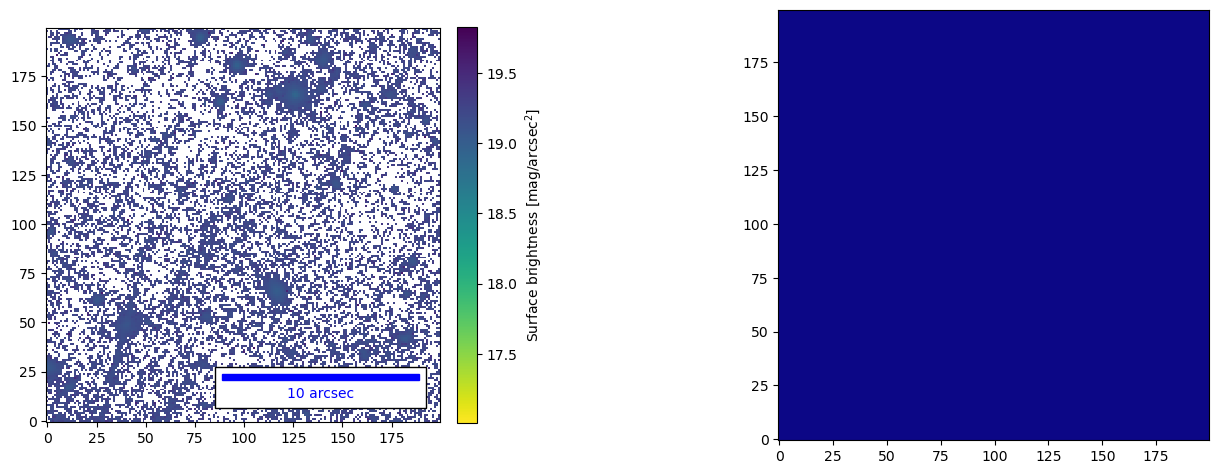

min_sb: 18.896
max_sb: 19.85209
Path: real_tidal_tails_crops_without_pedestal/NISP_J/VIS_28528_35473_NISP_9509_11824.fits


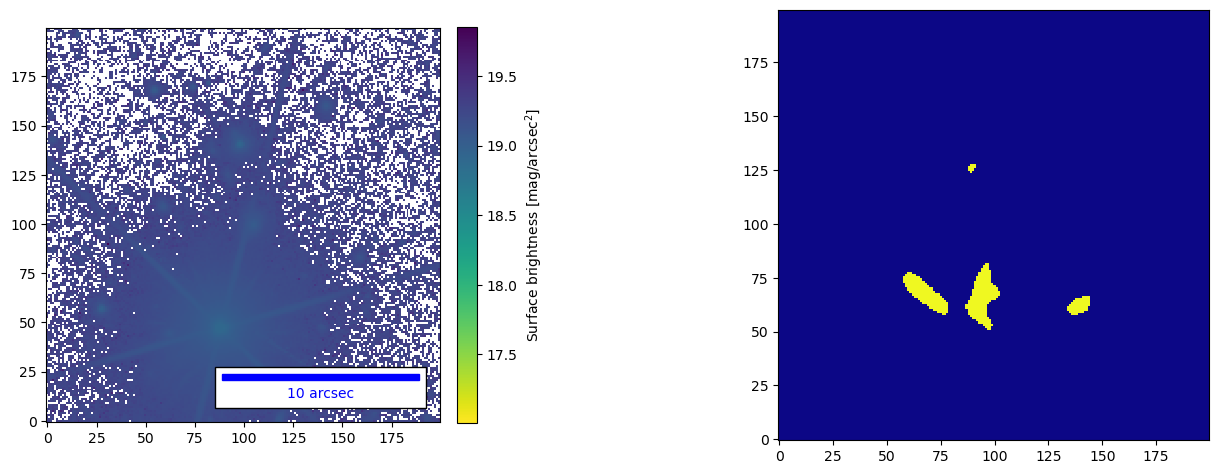

min_sb: 18.896
max_sb: 19.826004
Path: real_tidal_tails_crops_without_pedestal/NISP_J/VIS_4960_28347_NISP_1653_9449.fits


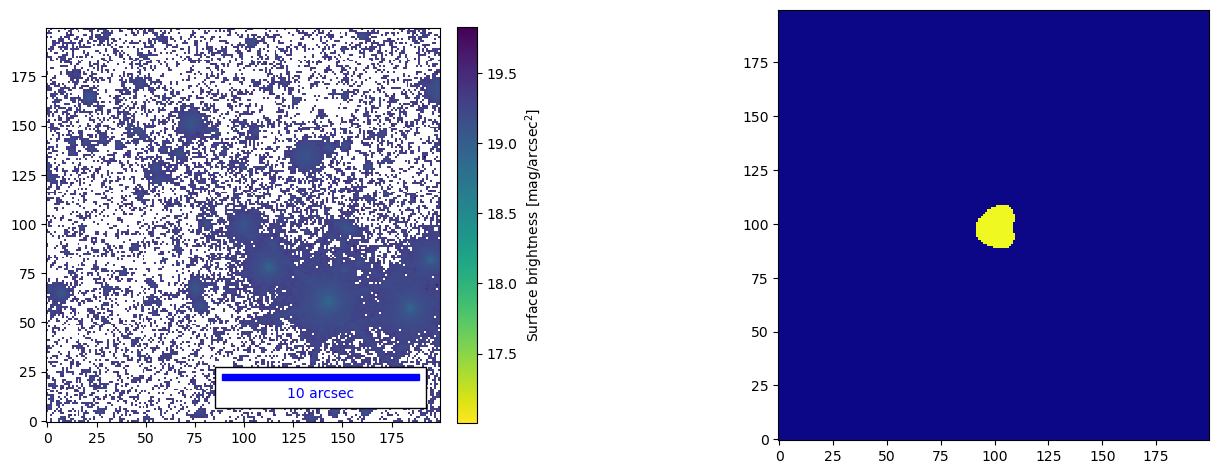

min_sb: 18.896
max_sb: 19.895056
Path: real_tidal_tails_crops_without_pedestal/NISP_J/VIS_6200_38554_NISP_2066_12851.fits


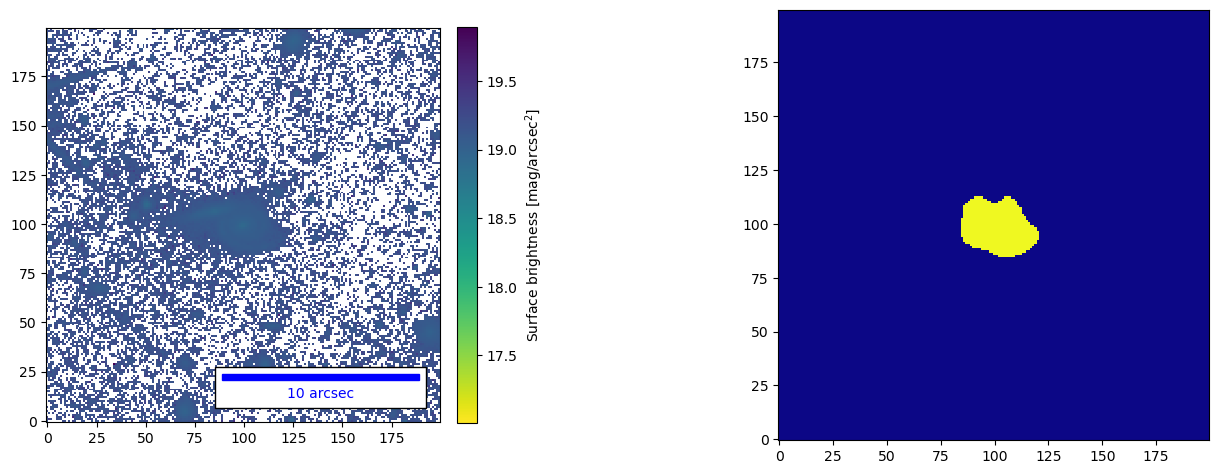

In [9]:
# ==========================================
# 2. EVALUACIÓN EN TEST DATASET
# ==========================================
ancho = hiperparametros['ancho_imagen_deseado']
alto = hiperparametros['alto_imagen_deseado']
mejor_modelo.eval()
pasos_test = 0
dice_medio_test = 0
iou_medio_test = 0
zp = 23.896
pix_scale = 0.1

for i in range(int(len(test_dataset)*1)):
    item_dataset = test_dataset.__getitem__(i)
    item_x = item_dataset[0].reshape((1,1,ancho,alto)).cpu().detach().squeeze().numpy()
    x_tensor_visualizar = item_dataset[0].reshape((1,1,ancho,alto)).cpu().detach().squeeze().numpy()

    # Obtenemos predicción de la red
    prediccion_item_tensor = mejor_modelo(item_dataset[0].reshape((1,1,ancho,alto)).to(device)).cpu().detach().squeeze()   
    mascara_predicha = torch.argmax(prediccion_item_tensor, dim=0).numpy()

    #Mostramos imagen, mascara y mascara predicha
    item_x = item_x.astype(np.float32)   
    mascara_predicha = mascara_predicha.astype(np.float32)  

    # Quitar el padding al mostrar
    crop = 12
    item_x = item_x[crop:-crop, crop:-crop]
    mascara_predicha = mascara_predicha[crop:-crop, crop:-crop]

    x_tensor_visualizar = x_tensor_visualizar[crop:-crop, crop:-crop]
    zeros = np.zeros((hiperparametros['ancho_imagen_original'], hiperparametros['ancho_imagen_original']))
    ones = np.ones((hiperparametros['ancho_imagen_original'], hiperparametros['ancho_imagen_original']))

    fig, (axs0, axs1) = plt.subplots(1, 2, figsize=(15, 15))

    sb_array = -2.5 * np.log10(x_tensor_visualizar) + zp + (5 * np.log10(pix_scale))

    # Filtrar inf y nan para calcular los límites
    sb_valid = sb_array[np.isfinite(sb_array)]
    min_sb = np.min(sb_valid)
    max_sb = np.max(sb_valid)

    print("min_sb: "+ str(min_sb))
    print("max_sb: "+ str(max_sb))
    print("Path: " + str(item_dataset[2]))
    # Usar axs0 en lugar de plt
    imshow_img = axs0.imshow(sb_array, origin='lower', interpolation="none", cmap="viridis_r", vmin=max_sb, vmax=min_sb)
    cb = fig.colorbar(imshow_img, ax=axs0, fraction=0.046, pad=0.04)
    cb.set_label(r'Surface brightness [mag/arcsec$^{2}$]')

    # Usar axs0.transData en lugar de plt.gca().transData
    scalebar = AnchoredSizeBar(axs0.transData, 10./pix_scale, "10 arcsec", borderpad=1.0, sep=5, loc="lower right", pad=0.5, color="blue", frameon=True, size_vertical=3)
    axs0.add_artist(scalebar)

    axs1.imshow(mascara_predicha, interpolation='none', origin="lower", cmap="plasma")
    plt.subplots_adjust(wspace=0.7)
    plt.show()